In [4]:
import scipy.io
import numpy as np
from sklearn.feature_selection import SelectKBest, mutual_info_classif, VarianceThreshold, RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# --- INPUT ---
input_mat = '/Users/aryanjaswal/Projects/IMAGINE MAT/DATASET/DATASET (NEW)/a.mat'   # Replace with your actual mat file
output_mat = 'a_selected.mat'

# --- LOAD ---
mat = scipy.io.loadmat(input_mat)
eeg_key = [k for k in mat.keys() if not k.startswith('__')][0]
eeg_data = mat[eeg_key]  # shape: (n_trials, 1) or (8, 100), dtype=object

n_rows, n_cols = eeg_data.shape
selected_data = np.empty((n_rows, n_cols), dtype=object)

for i in range(n_rows):
    for j in range(n_cols):
        X_raw = eeg_data[i, j]  # shape: (60, T)

        if not isinstance(X_raw, np.ndarray) or X_raw.ndim != 2 or X_raw.shape[0] < 20:
            selected_data[i, j] = X_raw
            continue

        # --- Feature Simulation ---
        y = np.array([0, 1, 1])  # synthetic labels
        X_feat = []
        for noise in [-0.05, 0, 0.05]:
            feat = np.mean(X_raw + noise * np.random.randn(*X_raw.shape), axis=1)
            X_feat.append(feat.reshape(1, -1))
        X_feat = np.vstack(X_feat)

        # --- Variance Filter ---
        vt = VarianceThreshold(1e-6)
        try:
            X_vt = vt.fit_transform(X_feat)
            idx_vt = vt.get_support(indices=True)
        except:
            selected_data[i, j] = X_raw
            continue

        # --- MI Filter ---
        if len(idx_vt) < 20:
            selected_data[i, j] = X_raw[idx_vt, :]
            continue
        mi_sel = SelectKBest(mutual_info_classif, k=min(40, X_vt.shape[1]))
        X_mi = mi_sel.fit_transform(X_vt, y)
        idx_mi = idx_vt[mi_sel.get_support(indices=True)]

        # --- RFECV ---
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        rfecv = RFECV(model, cv=StratifiedKFold(2), step=1, scoring='accuracy', min_features_to_select=20)
        rfecv.fit(X_feat[:, idx_mi], y)
        idx_final = idx_mi[rfecv.get_support(indices=True)[:20]]

        # --- Final selection ---
        selected_data[i, j] = X_raw[idx_final, :]

# --- SAVE ---
scipy.io.savemat(output_mat, {'eeg_selected': selected_data})
print(f"✅ Saved top-20 channels to {output_mat}")


✅ Saved top-20 channels to a_selected.mat


In [ ]:
import scipy.io
import numpy as np
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

# --------- STEP 1: Load EEG Data ---------
input_mat = '/Users/aryanjaswal/Projects/IMAGINE MAT/DATASET/DATASET (NEW)/a.mat'  # Replace with your filename
output_mat = 'your_file_top40.mat'

mat = scipy.io.loadmat(input_mat)
eeg_key = [k for k in mat.keys() if not k.startswith('__')][0]
eeg_data = mat[eeg_key]  # e.g., shape (8, 100), each cell: (64, T)

rows, cols = eeg_data.shape
print(f"Loaded EEG matrix of shape: {eeg_data.shape}")

# --------- STEP 2: Extract Global Features for Ranking ---------
X_all = []  # each row: one trial’s 64-channel mean features
y_all = []  # synthetic class label (row index used as placeholder)

for i in range(rows):
    for j in range(cols):
        sample = eeg_data[i, j]
        if isinstance(sample, np.ndarray) and sample.shape[0] == 64:
            # Feature: mean across time per channel → shape (64,)
            X_all.append(np.mean(sample, axis=1))
            y_all.append(i)  # use row index as class label proxy

X_all = np.array(X_all)  # shape: (n_samples, 64)
y_all = np.array(y_all)

print(f"Total samples for feature selection: {X_all.shape[0]}")

# --------- STEP 3: Select Top 40 Channels ---------
selector = SelectKBest(score_func=mutual_info_classif, k=40)
selector.fit(X_all, y_all)

top40_indices = selector.get_support(indices=True)
print(f"✅ Selected Top 40 EEG Channel Indices (0-based):\n{top40_indices}")

# Save indices if needed
np.save("top40_channel_indices.npy", top40_indices)

# --------- STEP 4: Rebuild EEG with Top 40 Channels ---------
selected_data = np.empty((rows, cols), dtype=object)

for i in range(rows):
    for j in range(cols):
        sample = eeg_data[i, j]
        if isinstance(sample, np.ndarray) and sample.shape[0] >= 64:
            selected_data[i, j] = sample[top40_indices, :]
        else:
            selected_data[i, j] = sample  # leave unchanged if invalid

# --------- STEP 5: Save to New .mat File ---------
scipy.io.savemat(output_mat, {'eeg_selected': selected_data})
print(f"✅ Saved top-40-channel EEG data to: {output_mat}")

Loaded EEG matrix of shape: (8, 100)
Total samples for feature selection: 800
✅ Selected Top 40 EEG Channel Indices (0-based):
[ 0  1  3  4  5  6  7  8  9 10 11 14 20 22 24 26 27 29 30 31 32 33 34 36
 37 38 39 40 41 42 43 45 48 51 56 58 59 60 61 63]
✅ Saved top-40-channel EEG data to: your_file_top40.mat


In [5]:
import scipy.io
import numpy as np
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from scipy.stats import entropy, skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# -------- Step 1: Load EEG Data --------
input_mat = '/Users/aryanjaswal/Projects/IMAGINE MAT/DATASET/DATASET (NEW)/cooperate.mat'  # Replace with your filename
output_mat = 'cooperate_top40.mat'

mat = scipy.io.loadmat(input_mat)
eeg_key = [k for k in mat.keys() if not k.startswith('__')][0]
eeg_data = mat[eeg_key]  # shape: (rows, cols), each cell: (64, T)

rows, cols = eeg_data.shape
print(f"EEG data loaded: {eeg_data.shape}")

# -------- Step 2: Feature Extraction --------
def extract_features(signal_2d):
    """Extract rich features from each of the 64 channels"""
    features = []
    for ch in signal_2d:
        ch = np.array(ch)
        ch = ch - np.min(ch) + 1e-6  # shift to positive for entropy
        features.append([
            np.mean(ch),
            np.std(ch),
            entropy(ch / np.sum(ch)),
            skew(ch),
            kurtosis(ch)
        ])
    return np.array(features).flatten()  # shape: (64*5,)

X = []
y = []
trial_indices = []

for i in range(rows):
    for j in range(cols):
        trial = eeg_data[i, j]
        if isinstance(trial, np.ndarray) and trial.shape[0] == 64:
            X.append(extract_features(trial))  # shape: (320,)
            y.append(i)  # dummy label (e.g. class index by row)
            trial_indices.append((i, j))

X = np.array(X)
y = np.array(y)
print(f"Feature matrix shape: {X.shape}")

# -------- Step 3: RFECV + Random Forest --------
model = RandomForestClassifier(n_estimators=300, random_state=42)
rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(5),
              scoring='accuracy', min_features_to_select=40)
rfecv.fit(X, y)

# Get final selected features → map to channels
selected_feature_indices = np.where(rfecv.support_)[0]
selected_channels = sorted(set(i // 5 for i in selected_feature_indices))[:40]

print(f"\n✅ Top 40 Channels (0-based): {selected_channels}")

# -------- Step 4: Build New EEG Dataset --------
new_data = np.empty((rows, cols), dtype=object)
for i in range(rows):
    for j in range(cols):
        trial = eeg_data[i, j]
        if isinstance(trial, np.ndarray) and trial.shape[0] == 64:
            new_data[i, j] = trial[selected_channels, :]
        else:
            new_data[i, j] = trial  # leave as is if invalid

# -------- Step 5: Save New .mat File --------
scipy.io.savemat(output_mat, {
    'eeg_selected': new_data,
    'top40_channel_indices': np.array(selected_channels)
})
print(f"\n✅ Saved reduced EEG data with top 40 channels to: {output_mat}")

EEG data loaded: (6, 100)
Feature matrix shape: (600, 320)

✅ Top 40 Channels (0-based): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43]

✅ Saved reduced EEG data with top 40 channels to: cooperate_top40.mat


In [6]:
import scipy.io
import numpy as np
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from scipy.stats import entropy, kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

# --- STEP 1: Load EEG Data ---
input_mat = '/Users/aryanjaswal/Projects/IMAGINE MAT/DATASET/DATASET (NEW)/i.mat'   # Replace with your .mat file path
output_mat = 'i_top40_fixed.mat'

mat = scipy.io.loadmat(input_mat)
eeg_key = [k for k in mat.keys() if not k.startswith('__')][0]
eeg_data = mat[eeg_key]  # shape: (rows, cols), each cell: (64, T)

rows, cols = eeg_data.shape
print(f"Loaded EEG data: {eeg_data.shape}")

# --- STEP 2: Feature Extraction from Each Trial ---
def extract_features(signal_2d):
    """Extract statistical features from each channel"""
    features = []
    for ch in signal_2d:
        ch = np.array(ch)
        ch = ch - np.min(ch) + 1e-6  # shift for entropy stability
        features.append([
            np.mean(ch),
            np.std(ch),
            entropy(ch / np.sum(ch)),
            skew(ch),
            kurtosis(ch)
        ])
    return np.array(features).flatten()  # shape: (64 * 5,)

X = []
y = []
valid_trials = []

for i in range(rows):
    for j in range(cols):
        trial = eeg_data[i, j]
        if isinstance(trial, np.ndarray) and trial.shape[0] == 64:
            X.append(extract_features(trial))
            y.append(i)  # dummy label (can replace with real class if available)
            valid_trials.append((i, j))

X = np.array(X)
y = np.array(y)
print(f"Extracted feature matrix: {X.shape}")

# --- STEP 3: RFECV + Force Exactly 40 Channels ---
model = RandomForestClassifier(n_estimators=300, random_state=42)
rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(5),
              scoring='accuracy', min_features_to_select=40)
rfecv.fit(X, y)

# Convert selected feature indices to channel indices
selected_feat_indices = np.where(rfecv.support_)[0]
selected_channel_indices = sorted(set(i // 5 for i in selected_feat_indices))

# Ensure exactly 40 channels
if len(selected_channel_indices) < 40:
    # Rank channel importance from trained model
    importances = rfecv.estimator_.feature_importances_
    channel_scores = np.zeros(64)
    for i, imp in enumerate(importances):
        channel_scores[i // 5] += imp
    sorted_by_importance = np.argsort(channel_scores)[::-1]

    for ch in sorted_by_importance:
        if ch not in selected_channel_indices:
            selected_channel_indices.append(ch)
        if len(selected_channel_indices) == 40:
            break

selected_channel_indices = sorted(selected_channel_indices)
print(f"✅ Final selected 40 channels: {selected_channel_indices}")

# --- STEP 4: Create New EEG Matrix with Only 40 Channels ---
new_data = np.empty((rows, cols), dtype=object)

for i in range(rows):
    for j in range(cols):
        trial = eeg_data[i, j]
        if isinstance(trial, np.ndarray) and trial.shape[0] == 64:
            new_data[i, j] = trial[selected_channel_indices, :]
        else:
            # if trial is invalid or already processed, keep as is
            new_data[i, j] = np.zeros((40, 1))  # pad with empty 40x1

# --- STEP 5: Save to .mat File ---
scipy.io.savemat(output_mat, {
    'eeg_selected': new_data,
    'top40_channel_indices': np.array(selected_channel_indices)
})
print(f"\n✅ Saved fixed top-40 channel EEG data to: {output_mat}")

Loaded EEG data: (8, 100)
Extracted feature matrix: (800, 320)
✅ Final selected 40 channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 13, 14, 20, 21, 22, 23, 25, 26, 27, 29, 30, 31, 33, 34, 35, 36, 37, 38, 40, 41, 44, 47, 48, 49, 50, 53, 57, 58, 60, 62]

✅ Saved fixed top-40 channel EEG data to: i_top40_fixed.mat


In [6]:



# segment Window Size.  Step Size.    Overlap %.    Segments in 5 sec
#.            3 sec.      1 sec.          66%              3


import numpy as np
from scipy.io import loadmat, savemat

# Load original EEG data
data = loadmat('/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/mat data/cooperate_top40.mat')
mat_key = 'eeg_selected'
eeg_data = data[mat_key]
print("Original EEG shape:", eeg_data.shape)  # (8, 100)

# Settings
fs = 256  # Sampling frequency
window_size = 3 * fs  # 3 seconds = 768 samples
step_size = 1 * fs    # 1 second = 256 samples
segments_per_trial = 3  # 5 sec trial → 3 segments (66% overlap)

# Shape placeholders
rows, cols = eeg_data.shape
combined_data = np.empty((rows, cols * segments_per_trial), dtype=object)

# Segment with overlap
for i in range(rows):
    for j in range(cols):
        signal = eeg_data[i, j]
        if isinstance(signal, np.ndarray) and signal.shape[1] >= window_size:
            for k in range(segments_per_trial):
                start = k * step_size
                end = start + window_size
                if end <= signal.shape[1]:
                    combined_data[i, j * segments_per_trial + k] = signal[:, start:end]
                else:
                    print(f"⚠️ Segment out of bounds at ({i}, {j}, {k})")
        else:
            print(f"⚠️ Unexpected shape at ({i}, {j}):", signal.shape)

# Save final .mat file
savemat('cooperate_3sec.mat', {mat_key: combined_data})
print("Available keys:", data.keys())


print("✅ Final combined file with 3s window & 1s step saved. Shape:", combined_data.shape)

Original EEG shape: (6, 100)
Available keys: dict_keys(['__header__', '__version__', '__globals__', 'eeg_selected', 'top40_channel_indices'])
✅ Final combined file with 3s window & 1s step saved. Shape: (6, 300)


In [9]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import welch
from scipy.integrate import simps
from scipy.stats import kurtosis, skew
import pywt

# Set sampling frequency
fs = 256

# --- Feature Functions ---

def spectral_entropy(psd):
    psd_norm = psd / np.sum(psd)
    return -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

def hjorth_params(signal):
    d1 = np.diff(signal)
    d2 = np.diff(d1)
    activity = np.var(signal)
    mobility = np.std(d1) / (np.std(signal) + 1e-12)
    complexity = (np.std(d2) / (np.std(d1) + 1e-12)) / (mobility + 1e-12)
    return activity, mobility, complexity

def wavelet_entropy(signal, wavelet='db4', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = np.array([np.sum(c**2) for c in coeffs])
    probs = energies / (np.sum(energies) + 1e-12)
    entropy = -np.sum(probs * np.log2(probs + 1e-12))
    return entropy, np.sum(energies)

def frequency_statistics(freqs, psd):
    psd_norm = psd / np.sum(psd)
    mean_freq = np.sum(freqs * psd_norm)
    median_freq = freqs[np.searchsorted(np.cumsum(psd_norm), 0.5)]
    peak_freq = freqs[np.argmax(psd)]
    freq_var = np.sum((freqs - mean_freq) ** 2 * psd_norm)
    return mean_freq, median_freq, freq_var, peak_freq

# --- Feature Extractor for One Trial (averaged over 64 channels) ---

def extract_mean_features(trial):  # trial shape: (64, 640)
    feature_matrix = []
    for ch in trial:
        freqs, psd = welch(ch, fs=fs)

        # Time-domain features
        mean = np.mean(ch)
        std = np.std(ch)
        sk = skew(ch)
        kurt = kurtosis(ch)
        rms = np.sqrt(np.mean(ch**2))
        ptp = np.ptp(ch)

        # Hjorth features
        act, mob, comp = hjorth_params(ch)

        # Spectral features
        spec_ent = spectral_entropy(psd)
        total_power = simps(psd, freqs)
        mean_f, med_f, var_f, peak_f = frequency_statistics(freqs, psd)

        # Wavelet features
        wave_ent, coeff_energy = wavelet_entropy(ch)

        # Combine features
        features = [
            mean, std, sk, kurt, rms, ptp,
            act, mob, comp,
            spec_ent, total_power, wave_ent, coeff_energy,
            med_f, mean_f, var_f, peak_f
        ]
        feature_matrix.append(features)

    return np.mean(np.array(feature_matrix), axis=0)  # shape: (18,)

# --- Load EEG Data and Process All Trials ---

mat_path = "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/independent_3sec.mat"
mat_key = "eeg_selected"

data = loadmat(mat_path)
eeg_data = data[mat_key]  # shape: (8, 200)

all_mean_features = []

for i in range(eeg_data.shape[0]):
    for j in range(eeg_data.shape[1]):
        trial = eeg_data[i, j]  # shape: (64, 640)
        trial_feats = extract_mean_features(trial)
        all_mean_features.append(trial_feats)

X = np.array(all_mean_features)  # shape: (1600, 18)
print("✅ Final mean feature matrix shape:", X.shape)

# --- Save to CSV with Feature Labels ---

feature_names = [
    'mean', 'std', 'skewness', 'kurtosis', 'rms', 'peak_to_peak',
    'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity',
    'spectral_entropy', 'total_power', 'wavelet_entropy', 'coeff_energy',
    'median_frequency', 'mean_frequency', 'frequency_variance', 'peak_frequency'
]

csv_path = "independent_features.csv"
df = pd.DataFrame(X, columns=feature_names)
df.to_csv(csv_path, index=False)

print(f"✅ Mean features saved to: {csv_path}")

/var/folders/jg/v0bbfb4d6z31kv3sqwt32tr40000gn/T/ipykernel_936/1307541429.py:61: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  total_power = simps(psd, freqs)


✅ Final mean feature matrix shape: (1800, 17)
✅ Mean features saved to: independent_features.csv


In [14]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/independent_features.csv", header=None)

# Add '0' as the last column
df['label'] = 5

# Save the updated CSV
df.to_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/independent_features.csv", index=False, header=False)

In [15]:
import pandas as pd

# List your CSV files here
file_list = ["/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/a_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/i_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/u_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/cooperate_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/independent_features.csv",
            ]  # Replace with actual file names

all_labels = []

for file in file_list:
    df = pd.read_csv(file, header=None, skiprows=1)  # Skip header row
    last_col = df.iloc[:, -1]
    all_labels.extend(last_col.tolist())

# Convert to DataFrame and add "label" as first cell
label_df = pd.DataFrame(all_labels, columns=["label"])

# Save to CSV with header
label_df.to_csv("labels.csv", index=False)

In [18]:
import pandas as pd

# List your CSV files directly
csv_files =  ["/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/a_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/i_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/u_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/cooperate_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/independent_features.csv",
            ]

# List to store processed DataFrames
df_list = []

# Loop through each file
for file in csv_files:
    df = pd.read_csv(file)
    if df.columns[-1] == "5":
        df.drop("5", axis=1, inplace=True)  # Remove the column explicitly by label
    else:
        df.drop(df.columns[-1], axis=1, inplace=True)  # Fallback: drop last column
    df_list.append(df)

# Combine all dataframes vertically
combined_df = pd.concat(df_list, ignore_index=True)

# Save to a new CSV file
combined_df.to_csv('combined.csv', index=False)

print("Combined CSV saved as 'combined.csv' without the last column '5'")

Combined CSV saved as 'combined.csv' without the last column '5'



===== Random Forest =====
Fold 1: Accuracy = 0.4519
Fold 2: Accuracy = 0.4870
Fold 3: Accuracy = 0.4593
Fold 4: Accuracy = 0.4537
Fold 5: Accuracy = 0.4602
Fold 6: Accuracy = 0.4574
Fold 7: Accuracy = 0.4722
Fold 8: Accuracy = 0.4574
Fold 9: Accuracy = 0.4843
Fold 10: Accuracy = 0.4630
Average Accuracy = 0.4646

===== Decision Tree =====
Fold 1: Accuracy = 0.3463
Fold 2: Accuracy = 0.3667
Fold 3: Accuracy = 0.3648
Fold 4: Accuracy = 0.3509
Fold 5: Accuracy = 0.3472
Fold 6: Accuracy = 0.3361
Fold 7: Accuracy = 0.3481
Fold 8: Accuracy = 0.3787
Fold 9: Accuracy = 0.3546
Fold 10: Accuracy = 0.3398
Average Accuracy = 0.3533

===== Gradient Boosting =====
Fold 1: Accuracy = 0.4009
Fold 2: Accuracy = 0.4120
Fold 3: Accuracy = 0.4204
Fold 4: Accuracy = 0.4046
Fold 5: Accuracy = 0.4250
Fold 6: Accuracy = 0.4028
Fold 7: Accuracy = 0.4120
Fold 8: Accuracy = 0.3981
Fold 9: Accuracy = 0.4287
Fold 10: Accuracy = 0.4111
Average Accuracy = 0.4116


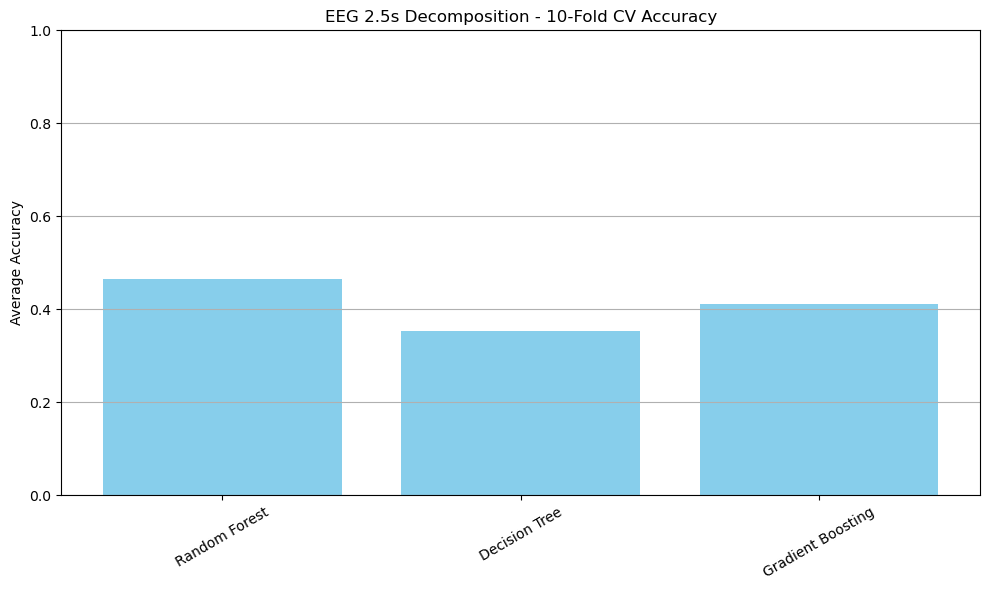

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load data
X = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/combined.csv', header=None, skiprows=1)
y = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/labels.csv', header=None, skiprows=1).squeeze()

# Feature scaling - improves SVM, KNN, etc.
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 10-fold stratified cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define models (with better tuned hyperparameters)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=4, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    # Optional: Add SVM or Logistic Regression with tuning
    
}

# Evaluate models
model_accuracies = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    fold = 1
    accuracies = []

    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold {fold}: Accuracy = {acc:.4f}")
        fold += 1

    avg_acc = sum(accuracies) / len(accuracies)
    model_accuracies[model_name] = avg_acc
    print(f"Average Accuracy = {avg_acc:.4f}")

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color='skyblue')
plt.ylabel('Average Accuracy')
plt.ylim(0, 1)
plt.title('EEG 2.5s Decomposition - 10-Fold CV Accuracy')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()
plt.show()